# 03 — Feature Engineering
## From EDA Insights to Model-Ready Features

**Purpose.** Transform the daily demand time series into a feature matrix where
every column is justified by a specific finding from the EDA (notebook 02).
No feature exists "because it might help" — every one traces back to a chart,
a correlation, or a pattern we actually observed.

**Input:** `daily_item_demand.csv` (from notebook 01 — 66,734 rows, 122 items × 547 days)

**Output:** `forecasting_features.csv` — same rows minus the first 28 days
(needed for lag history), enriched with ~60+ features ready for Prophet,
XGBoost, LightGBM, LSTM, and TFT.

---

### EDA Finding → Feature Mapping

| EDA Finding | Feature(s) |
|---|---|
| Weekly seasonality (Sat/Mon 1.5×) | `day_of_week` one-hot + cyclical sin/cos |
| Monthly seasonality (~30% swing) | `month` sin/cos encoding |
| Long-term growth (+15% / 18mo) | `days_since_start` |
| Ramadan suppression (uneven: -66% Cafe, -12% American) | `is_ramadan` + `is_ramadan × section` |
| Holiday spikes (desserts 6×, mains 3.5×) | `is_holiday` + `holiday × category` |
| Item seasonality (summer/winter inversions) | `month × section` interaction |
| Lag-7 autocorrelation (0.492) | `lag_1`, `lag_7`, `lag_14` |
| Rolling statistics | `rolling_mean_7`, `rolling_mean_14`, `rolling_std_7` |
| Section-level weekday patterns | `section × day_of_week` interaction |
| Price signal | `avg_price` (already present) |
| Cross-item learning gap (post-04c) | `total_lag_7`, `section_lag_7`, `section_rolling_7`, `item_share_of_section` |

**Feature priority** (from EDA): lag_7 > day_of_week > section × day_of_week > is_ramadan × section > month > lag_14 > rolling stats > holiday × category > trend > price

---

## 1. Setup and data loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# === ADJUST THIS PATH TO YOUR FOLDER LAYOUT ===
DATASETS_DIR = '../../datasets'
FE_DIR= '../Feature_engineering'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 10

print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\slimc\Desktop\Notebooks\Module 2\Feature_Engineering


In [2]:
# Load the daily demand table from notebook 01
df = pd.read_csv(os.path.join(DATASETS_DIR, 'daily_item_demand.csv'), parse_dates=['order_date'])
df = df.sort_values(['item_name', 'order_date']).reset_index(drop=True)

print(f"Loaded: {len(df):,} rows")
print(f"Date range: {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"Items: {df['item_name'].nunique()}")
print(f"Sections: {sorted(df['section'].unique())}")
print(f"Columns: {list(df.columns)}")
print(f"\nSplit distribution:")
print(df['split'].value_counts())
print(f"\nSample:")
df.head(10)

Loaded: 66,734 rows
Date range: 2023-01-01 → 2024-06-30
Items: 122
Sections: ['American', 'Cafe', 'Healthy_Vegan', 'Italian', 'Japanese', 'Mexican', 'Steakhouse']
Columns: ['order_date', 'item_name', 'quantity', 'section', 'category', 'avg_price', 'item_id', 'split']

Split distribution:
train    51850
val       7442
test      7442
Name: split, dtype: int64

Sample:


,order_date,item_name,quantity,section,category,avg_price,item_id,split
0,2023-01-01,14oz Ribeye,0,Steakhouse,Main,32.0,1,train
1,2023-01-02,14oz Ribeye,0,Steakhouse,Main,32.0,1,train
2,2023-01-03,14oz Ribeye,3,Steakhouse,Main,32.0,1,train
3,2023-01-04,14oz Ribeye,1,Steakhouse,Main,32.0,1,train
4,2023-01-05,14oz Ribeye,2,Steakhouse,Main,32.0,1,train
5,2023-01-06,14oz Ribeye,0,Steakhouse,Main,32.0,1,train
6,2023-01-07,14oz Ribeye,1,Steakhouse,Main,32.0,1,train
7,2023-01-08,14oz Ribeye,0,Steakhouse,Main,32.0,1,train
8,2023-01-09,14oz Ribeye,1,Steakhouse,Main,32.0,1,train
9,2023-01-10,14oz Ribeye,1,Steakhouse,Main,32.0,1,train


## 2. Calendar features

**EDA justification:**
- Weekly seasonality is the **strongest single signal** — Saturday sells 60% more than Monday, consistent across 18 months
- Monthly seasonality shows ~30% annual swing (Feb-Apr trough, Jul peak, Dec spike)
- Long-term growth of +14.8 items/year needs a linear trend feature

We build both **one-hot** (for tree models like XGBoost/LightGBM that can split on individual days) and **cyclical sin/cos** (for LSTM/TFT that need Sunday→Monday continuity).

In [3]:
# --- Day of week ---
df['day_of_week'] = df['order_date'].dt.dayofweek  # 0=Monday, 6=Sunday

# One-hot encoding (for tree models)
# Force the column order to match pandas day codes 0=Mon...6=Sun
dow_dummies = pd.get_dummies(df['day_of_week'], prefix='dow', dtype=int)
expected_order = [f'dow_{i}' for i in range(7)]
dow_dummies = dow_dummies.reindex(columns=expected_order, fill_value=0)
dow_dummies.columns = ['dow_mon', 'dow_tue', 'dow_wed', 'dow_thu', 'dow_fri', 'dow_sat', 'dow_sun']
df = pd.concat([df, dow_dummies], axis=1)

# Cyclical encoding (for DL models — preserves Sunday→Monday adjacency)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Binary weekend flag (EDA showed fundamentally different weekend behavior)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# --- Month ---
df['month'] = df['order_date'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# --- Day of month (payday effects) ---
df['day_of_month'] = df['order_date'].dt.day

# --- Week of year (finer than month) ---
df['week_of_year'] = df['order_date'].dt.isocalendar().week.astype(int)
df['woy_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['woy_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

# --- Trend: days since start ---
# EDA showed +14.8 items/year linear growth
start_date = df['order_date'].min()
df['days_since_start'] = (df['order_date'] - start_date).dt.days

print("Calendar features added:")
print(f"  day_of_week (int), 7 one-hot dummies, sin/cos cyclical")
print(f"  month (int), sin/cos cyclical")
print(f"  day_of_month, week_of_year + sin/cos")
print(f"  is_weekend, days_since_start")
print(f"\nSample:")
df[['order_date', 'item_name', 'day_of_week', 'is_weekend', 'month', 'days_since_start']].head(7)

Calendar features added:
  day_of_week (int), 7 one-hot dummies, sin/cos cyclical
  month (int), sin/cos cyclical
  day_of_month, week_of_year + sin/cos
  is_weekend, days_since_start

Sample:


,order_date,item_name,day_of_week,is_weekend,month,days_since_start
0,2023-01-01,14oz Ribeye,6,1,1,0
1,2023-01-02,14oz Ribeye,0,0,1,1
2,2023-01-03,14oz Ribeye,1,0,1,2
3,2023-01-04,14oz Ribeye,2,0,1,3
4,2023-01-05,14oz Ribeye,3,0,1,4
5,2023-01-06,14oz Ribeye,4,0,1,5
6,2023-01-07,14oz Ribeye,5,1,1,6


In [4]:
# Verify the dow one-hot encoding is correct
sample = df[['day_of_week', 'dow_mon', 'dow_tue', 'dow_wed', 'dow_thu', 'dow_fri', 'dow_sat', 'dow_sun']].head(7)
print(sample)

   day_of_week  dow_mon  dow_tue  dow_wed  dow_thu  dow_fri  dow_sat  dow_sun
0            6        0        0        0        0        0        0        1
1            0        1        0        0        0        0        0        0
2            1        0        1        0        0        0        0        0
3            2        0        0        1        0        0        0        0
4            3        0        0        0        1        0        0        0
5            4        0        0        0        0        1        0        0
6            5        0        0        0        0        0        1        0


## 3. Ramadan features

**EDA justification:**
- Ramadan crashes demand to ~100 items/day from ~160 baseline
- Impact is **wildly uneven**: Cafe and Healthy_Vegan at -66%, American only -12%
- Reason: daytime beverages/light meals disappear during fasting; comfort food holds as iftar choice
- A flat `is_ramadan` binary would overpredict Cafe and underpredict American
- **Need:** `is_ramadan` + `is_ramadan × section` interaction + pre/post windows

Ramadan dates in the dataset range:
- **2023:** March 22 → April 20 (30 days)
- **2024:** March 11 → April 9 (30 days, shifted ~11 days earlier — lunar calendar)

In [5]:
# ── Ramadan periods ──
ramadan_periods = [
    ('2023-03-22', '2023-04-20'),  # Ramadan 2023
    ('2024-03-11', '2024-04-09'),  # Ramadan 2024
]

# Binary flag
df['is_ramadan'] = 0
for start, end in ramadan_periods:
    mask = (df['order_date'] >= start) & (df['order_date'] <= end)
    df.loc[mask, 'is_ramadan'] = 1

# Day within Ramadan (1-30) — captures progressive fasting effect
# Early Ramadan may differ from late Ramadan (fatigue, routine adaptation)
df['ramadan_day'] = 0
for start, end in ramadan_periods:
    mask = (df['order_date'] >= start) & (df['order_date'] <= end)
    start_dt = pd.Timestamp(start)
    df.loc[mask, 'ramadan_day'] = (df.loc[mask, 'order_date'] - start_dt).dt.days + 1

# Post-Ramadan rebound (7-day window after Eid)
# EDA showed demand overshoots after fasting ends
df['is_post_ramadan'] = 0
for _, end in ramadan_periods:
    end_dt = pd.Timestamp(end)
    mask = (df['order_date'] > end_dt) & (df['order_date'] <= end_dt + pd.Timedelta(days=7))
    df.loc[mask, 'is_post_ramadan'] = 1

# Pre-Ramadan window (7 days before — anticipation / last meals out)
df['is_pre_ramadan'] = 0
for start, _ in ramadan_periods:
    start_dt = pd.Timestamp(start)
    mask = (df['order_date'] >= start_dt - pd.Timedelta(days=7)) & (df['order_date'] < start_dt)
    df.loc[mask, 'is_pre_ramadan'] = 1

# ── Ramadan × section interaction ──
# THE KEY INSIGHT: Ramadan means -66% for Cafe but -12% for American
sections = sorted(df['section'].unique())
for sec in sections:
    col = f'ramadan_x_{sec.lower().replace("_", "").replace(" ", "_")}'
    df[col] = df['is_ramadan'] * (df['section'] == sec).astype(int)

print(f"Ramadan rows flagged: {df['is_ramadan'].sum():,} ({df['is_ramadan'].mean()*100:.1f}%)")
print(f"Post-Ramadan rows:    {df['is_post_ramadan'].sum():,}")
print(f"Pre-Ramadan rows:     {df['is_pre_ramadan'].sum():,}")
print(f"Section interactions:  {len(sections)} columns")
print(f"\nMean demand during Ramadan by section:")
ram = df[df['is_ramadan'] == 1].groupby('section')['quantity'].mean()
noram = df[df['is_ramadan'] == 0].groupby('section')['quantity'].mean()
impact = ((ram / noram - 1) * 100).round(1)
print(impact.to_string())

Ramadan rows flagged: 7,320 (11.0%)
Post-Ramadan rows:    1,708
Pre-Ramadan rows:     1,708
Section interactions:  7 columns

Mean demand during Ramadan by section:
section
American        -28.9
Cafe            -69.8
Healthy_Vegan   -70.0
Italian         -34.1
Japanese        -21.5
Mexican         -28.1
Steakhouse      -27.5


## 4. Holiday features

**EDA justification:**
- NYE 2023 showed 2-6× demand lift — Tiramisu at 6.4× normal Sunday
- Desserts and shareable items spike harder than mains (6× vs 3.5×)
- December overall is the highest month (5,860 beating July's 5,593)
- **Need:** `is_holiday` + `holiday_type` + proximity features + `holiday × category` interaction

In [6]:
# ── Define holidays in the dataset range ──
# Includes both secular and Islamic holidays relevant to the data
holidays = {
    # ── 2023 ──
    '2023-01-01': 'new_year',
    '2023-04-21': 'eid_al_fitr',    # End of Ramadan 2023
    '2023-04-22': 'eid_al_fitr',
    '2023-04-23': 'eid_al_fitr',
    '2023-06-28': 'eid_al_adha',
    '2023-06-29': 'eid_al_adha',
    '2023-06-30': 'eid_al_adha',
    '2023-07-25': 'national',        # Tunisia Republic Day
    '2023-08-13': 'national',        # Women's Day (Tunisia)
    '2023-10-15': 'national',        # Evacuation Day
    '2023-12-25': 'christmas',
    '2023-12-31': 'new_year_eve',
    # ── 2024 ──
    '2024-01-01': 'new_year',
    '2024-01-14': 'national',        # Revolution Day
    '2024-03-20': 'national',        # Independence Day
    '2024-04-10': 'eid_al_fitr',    # End of Ramadan 2024
    '2024-04-11': 'eid_al_fitr',
    '2024-04-12': 'eid_al_fitr',
    '2024-06-16': 'eid_al_adha',
    '2024-06-17': 'eid_al_adha',
    '2024-06-18': 'eid_al_adha',
}

# Binary flag
df['is_holiday'] = df['order_date'].dt.strftime('%Y-%m-%d').isin(holidays).astype(int)

# Holiday type
df['holiday_type'] = df['order_date'].dt.strftime('%Y-%m-%d').map(
    lambda x: holidays.get(x, 'none')
)

# Label encode holiday type (for tree models)
holiday_type_map = {
    'none': 0, 'new_year': 1, 'new_year_eve': 2,
    'eid_al_fitr': 3, 'eid_al_adha': 4,
    'national': 5, 'christmas': 6,
}
df['holiday_type_encoded'] = df['holiday_type'].map(holiday_type_map).fillna(0).astype(int)

print(f"Holiday rows: {df['is_holiday'].sum():,}")
print(f"\nHoliday breakdown:")
print(df[df['is_holiday'] == 1].groupby('holiday_type')['order_date'].apply(
    lambda x: f"{x.nunique()} days"
).to_string())

Holiday rows: 2,562

Holiday breakdown:
holiday_type
christmas       1 days
eid_al_adha     6 days
eid_al_fitr     6 days
national        5 days
new_year        2 days
new_year_eve    1 days


In [7]:
# ── Proximity to nearest holiday ──
holiday_dates = sorted(pd.to_datetime(list(holidays.keys())))
unique_dates = sorted(df['order_date'].unique())

# Precompute for efficiency
date_proximity = {}
for d in unique_dates:
    d_ts = pd.Timestamp(d)  # normalize type
    past = [h for h in holiday_dates if h <= d_ts]
    future = [h for h in holiday_dates if h > d_ts]
    since = (d_ts - past[-1]).days if past else 999
    to_next = (future[0] - d_ts).days if future else 999
    date_proximity[d_ts] = (min(since, 30), min(to_next, 30))

df['days_since_holiday'] = df['order_date'].map(lambda x: date_proximity[pd.Timestamp(x)][0])
df['days_to_holiday'] = df['order_date'].map(lambda x: date_proximity[pd.Timestamp(x)][1])

# ── Holiday × category interaction ──
categories = sorted(df['category'].unique())
for cat in categories:
    col = f'holiday_x_{cat.lower().replace(" ", "_").replace("/", "_")}'
    df[col] = df['is_holiday'] * (df['category'] == cat).astype(int)

print(f"Holiday proximity features: days_since_holiday, days_to_holiday (capped at 30)")
print(f"Holiday × category interactions: {len(categories)} columns")
print(f"Categories: {categories}")

Holiday proximity features: days_since_holiday, days_to_holiday (capped at 30)
Holiday × category interactions: 8 columns
Categories: ['Alcohol', 'Appetizer', 'Bakery', 'Beverage', 'Dessert', 'Food', 'Main', 'Side']


## 5. Lag features

**EDA justification (autocorrelation analysis):**
- **Lag-7 = 0.492** — same day last week is the strongest single predictor
- **Lag-1 = ~0.44** — yesterday's demand has moderate predictive power (momentum)
- **Lag-14 = 0.443** — two weeks ago still useful
- **Lag-21 = 0.390, Lag-28 = 0.324** — diminishing returns beyond 2 weeks
- Non-weekly lags (3, 4, 5, 8, 9, 10) are near zero — no mid-week sub-cycles

**Critical:** all lags are computed **per item** (Espresso's lag-7 ≠ Tiramisu's lag-7)
and use `shift()` to prevent data leakage — we only see data up to yesterday.

In [8]:
# Sort by item + date (required for correct shift alignment)
df = df.sort_values(['item_name', 'order_date']).reset_index(drop=True)

# ── Primary lag features ──
lag_days = [1, 2, 3, 7, 14, 21, 28]

for lag in lag_days:
    df[f'lag_{lag}'] = df.groupby('item_name')['quantity'].shift(lag)

# ── Derived lag features ──

# Lag-7 ratio: how does last week compare to the item's recent baseline?
# Normalizes across items with different volume levels
df['lag7_ratio'] = df['lag_7'] / (df['lag_14'] + 1)  # +1 avoids div/0

# Week-over-week acceleration: is demand trending up or down?
df['lag_7_14_diff'] = df['lag_7'] - df['lag_14']

# Same weekday, 4 weeks of history: captures if this weekday is consistently strong
df['lag_7_28_mean'] = (df['lag_7'] + df['lag_14'] + df['lag_21'] + df['lag_28']) / 4

print(f"Lag features created: {len(lag_days)} raw lags + 3 derived")
print(f"NaN rows from lag-28 (first 28 days per item): {df['lag_28'].isna().sum():,}")
print(f"These will be dropped in the cleanup step")

Lag features created: 7 raw lags + 3 derived
NaN rows from lag-28 (first 28 days per item): 3,416
These will be dropped in the cleanup step


## 6. Rolling window features

**EDA justification:**
- The 30-day rolling average in the trend chart was smooth and informative
- Rolling std captures demand volatility (critical for safety stock in notebook 08)
- Different windows capture different dynamics:
  - **7-day** = weekly rhythm and recent behavior
  - **14-day** = bi-weekly patterns
  - **28-day** = monthly baseline level

**All rolling features use `shift(1)`** — the window only sees data up to
yesterday, never today's actual quantity. This is the most common source of
data leakage in time series projects.

In [9]:
# ── 7-day rolling (weekly rhythm) ──
df['rolling_mean_7'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)
df['rolling_std_7'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).std()
)
df['rolling_max_7'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).max()
)
df['rolling_min_7'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).min()
)

# ── 14-day rolling (bi-weekly) ──
df['rolling_mean_14'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=1).mean()
)
df['rolling_std_14'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=1).std()
)

# ── 28-day rolling (monthly baseline) ──
df['rolling_mean_28'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(28, min_periods=1).mean()
)

# ── Derived rolling features ──

# Coefficient of variation (volatility relative to mean — normalizes across items)
df['rolling_cv_7'] = df['rolling_std_7'] / (df['rolling_mean_7'] + 1e-6)

# Demand momentum: 7-day mean vs 28-day mean
# > 1 = recent demand above baseline (trending up)
# < 1 = recent demand below baseline (trending down)
df['demand_momentum'] = df['rolling_mean_7'] / (df['rolling_mean_28'] + 1e-6)

# Expanding mean — the item's historical average up to this point
df['expanding_mean'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).expanding(min_periods=1).mean()
)

print("Rolling features (all use shift(1) — no leakage):")
print("  7-day:  mean, std, max, min")
print("  14-day: mean, std")
print("  28-day: mean")
print("  Derived: cv_7, demand_momentum, expanding_mean")

Rolling features (all use shift(1) — no leakage):
  7-day:  mean, std, max, min
  14-day: mean, std
  28-day: mean
  Derived: cv_7, demand_momentum, expanding_mean


## 7. Hierarchical aggregate features (cross-item learning signal)

**EDA justification (added after first model run):**
- The Prophet/SARIMA comparison (notebook 04c) showed both methods hit a structural
  ceiling on low-volume items because per-item methods cannot borrow strength
  across items
- A global ML model can theoretically use cross-item information, but only if
  the features actually expose that information
- Per-item lag features tell the model what *this item* did before — not what
  *the section* or *the whole restaurant* did

**The fix:** add features that summarize demand at higher aggregation levels:
- Section-level: did demand for this section overall trend up/down recently?
- Total-level: was the whole restaurant busy or slow recently?
- Item share of section: is this item gaining or losing share within its section?

These give the global model a structural signal that per-item Prophet/SARIMA
fundamentally cannot see.

In [10]:
# ── Total restaurant daily demand context ──
# "Was the restaurant busy 7 days ago? Has it been busy recently?"
print("Building hierarchical aggregate features...")

daily_total = df.groupby('order_date')['quantity'].sum().rename('total_daily')
total_frame = pd.DataFrame({'total_daily': daily_total}).sort_index()
total_frame['total_lag_7'] = total_frame['total_daily'].shift(7)
total_frame['total_rolling_7'] = total_frame['total_daily'].shift(1).rolling(7, min_periods=1).mean()
total_frame = total_frame[['total_lag_7', 'total_rolling_7']]

df = df.merge(total_frame, left_on='order_date', right_index=True, how='left')

# ── Section-level daily demand context ──
# "Was Steakhouse busy overall last week? Is the whole section trending up?"
section_daily = df.groupby(['order_date', 'section'])['quantity'].sum().rename('section_daily').reset_index()
section_daily = section_daily.sort_values(['section', 'order_date']).reset_index(drop=True)
section_daily['section_lag_7'] = section_daily.groupby('section')['section_daily'].shift(7)
section_daily['section_rolling_7'] = section_daily.groupby('section')['section_daily'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)

df = df.merge(
    section_daily[['order_date', 'section', 'section_lag_7', 'section_rolling_7']],
    on=['order_date', 'section'], how='left'
)

# ── Item share of its section ──
# "Is this item more or less popular within its section than usual?"
# Uses the rolling_mean_7 we computed in section 6
df['item_share_of_section'] = df['rolling_mean_7'] / (df['section_rolling_7'] + 1e-6)

print(f"Hierarchical features added: 5 features")
print(f"  total_lag_7, total_rolling_7        — restaurant-wide context")
print(f"  section_lag_7, section_rolling_7    — section-level context")
print(f"  item_share_of_section               — item popularity within section")
print(f"\nSample (Hot Dog with Mustard, week of 2023-01-15):")
sample = df[(df['item_name']=='Hot Dog with Mustard') & 
            (df['order_date'] >= '2023-01-15') & 
            (df['order_date'] <= '2023-01-21')]
print(sample[['order_date', 'quantity', 'section_rolling_7', 
              'total_rolling_7', 'item_share_of_section']].to_string(index=False))

Building hierarchical aggregate features...
Hierarchical features added: 5 features
  total_lag_7, total_rolling_7        — restaurant-wide context
  section_lag_7, section_rolling_7    — section-level context
  item_share_of_section               — item popularity within section

Sample (Hot Dog with Mustard, week of 2023-01-15):
order_date  quantity  section_rolling_7  total_rolling_7  item_share_of_section
2023-01-15         4          25.285714       132.000000               0.096045
2023-01-16         3          24.285714       131.428571               0.111765
2023-01-17         1          27.714286       133.142857               0.103093
2023-01-18         4          26.000000       133.142857               0.093407
2023-01-19         3          29.000000       133.714286               0.093596
2023-01-20         5          33.142857       140.714286               0.090517
2023-01-21         4          35.571429       139.857143               0.092369


## 8. Section, category & item encoding

**EDA justification:**
- Sections have **completely different weekday patterns** — Healthy_Vegan peaks
  midweek while Steakhouse peaks weekends. A flat "Saturday = busy" assumption
  would overpredict Healthy_Vegan and underpredict Steakhouse.
- **Need:** section × day_of_week interaction so the model learns that Saturday
  means +30% for American but -25% for Healthy_Vegan.

In [11]:
# ── Label encoding ──
section_map = {s: i for i, s in enumerate(sorted(df['section'].unique()))}
category_map = {c: i for i, c in enumerate(sorted(df['category'].unique()))}
item_map = {item: i for i, item in enumerate(sorted(df['item_name'].unique()))}

df['section_encoded'] = df['section'].map(section_map)
df['category_encoded'] = df['category'].map(category_map)
df['item_encoded'] = df['item_name'].map(item_map)

# ── Section × weekend interaction ──
# Captures that weekend means opposite things for different sections
for sec in sections:
    col = f'section_x_weekend_{sec.lower()}'
    df[col] = df['is_weekend'] * (df['section'] == sec).astype(int)

print(f"Section encoding: {section_map}")
print(f"Categories: {len(category_map)}")
print(f"Items: {len(item_map)}")
print(f"Section × weekend interactions: {len(sections)} columns")

Section encoding: {'American': 0, 'Cafe': 1, 'Healthy_Vegan': 2, 'Italian': 3, 'Japanese': 4, 'Mexican': 5, 'Steakhouse': 6}
Categories: 8
Items: 122
Section × weekend interactions: 7 columns


## 9. Month × section interaction (item seasonality)

**EDA justification:**
- Summer/winter item inversions are dramatic (Iced Latte ↔ Cappuccino, 8× ratio)
- The **direction** of monthly seasonality depends on the section/item type
- Month alone won't capture this — need month × section interaction
- Using sin/cos × section (14 columns) instead of full one-hot cross (84 columns)

In [12]:
for sec in sections:
    sec_clean = sec.lower()
    sec_mask = (df['section'] == sec).astype(float)
    df[f'month_sin_x_{sec_clean}'] = df['month_sin'] * sec_mask
    df[f'month_cos_x_{sec_clean}'] = df['month_cos'] * sec_mask

print(f"Month × section interactions: {len(sections) * 2} columns (sin + cos × {len(sections)} sections)")

Month × section interactions: 14 columns (sin + cos × 7 sections)


## 10. Handle NaN from lag/rolling features

The first 28 days per item have incomplete lag history (lag-28 needs 28 days
of prior data). We drop these rows — losing 28 × 122 = ~3,400 rows (~5% of
the dataset). This is acceptable and prevents the model from training on
partial/misleading lag values.

In [13]:
nan_before = df.isna().sum().sum()
print(f"Total NaN before cleanup: {nan_before:,}")

# Drop the first 28 days of the dataset (all items share the same date range)
min_date_for_features = df['order_date'].min() + pd.Timedelta(days=28)
df_feat = df[df['order_date'] >= min_date_for_features].copy()

# Fill any remaining edge-case NaN in rolling features
rolling_cols = [c for c in df_feat.columns if 'rolling' in c or 'expanding' in c]
df_feat[rolling_cols] = df_feat[rolling_cols].fillna(0)

# Fill derived feature NaN
df_feat['lag7_ratio'] = df_feat['lag7_ratio'].fillna(1.0)
df_feat['lag_7_14_diff'] = df_feat['lag_7_14_diff'].fillna(0)
df_feat['lag_7_28_mean'] = df_feat['lag_7_28_mean'].fillna(0)
df_feat['demand_momentum'] = df_feat['demand_momentum'].fillna(1.0)
df_feat['rolling_cv_7'] = df_feat['rolling_cv_7'].fillna(0)
df_feat['rolling_std_7'] = df_feat['rolling_std_7'].fillna(0)
df_feat['rolling_std_14'] = df_feat['rolling_std_14'].fillna(0)

# Fill hierarchical aggregate features (added in section 7)
# total_rolling_7 and section_rolling_7 are already covered by rolling_cols above
df_feat['total_lag_7'] = df_feat['total_lag_7'].fillna(df_feat['total_lag_7'].median())
df_feat['section_lag_7'] = df_feat.groupby('section')['section_lag_7'].transform(
    lambda x: x.fillna(x.median())
)
df_feat['item_share_of_section'] = df_feat['item_share_of_section'].fillna(0)

rows_dropped = len(df) - len(df_feat)
nan_after = df_feat.isna().sum().sum()
print(f"Dropped first 28 days: {rows_dropped:,} rows ({rows_dropped/len(df)*100:.1f}%)")
print(f"Remaining: {len(df_feat):,} rows")
print(f"NaN after cleanup: {nan_after}")

Total NaN before cleanup: 19,764
Dropped first 28 days: 3,416 rows (5.1%)
Remaining: 63,318 rows
NaN after cleanup: 0


## 11. Verify train / validation / test split

The split was defined in notebook 01 (chronological, no leakage):

| Split | Period | Purpose |
|---|---|---|
| **Train** | Jan 2023 → Feb 2024 | Learn patterns |
| **Validation** | Mar → Apr 2024 | Tune hyperparameters (includes Ramadan 2024) |
| **Test** | May → Jun 2024 | Final unseen evaluation |

We keep the same `split` column — just verify it survived the NaN cleanup.

In [14]:
split_summary = df_feat.groupby('split').agg(
    rows=('quantity', 'count'),
    days=('order_date', 'nunique'),
    date_min=('order_date', 'min'),
    date_max=('order_date', 'max'),
    mean_qty=('quantity', 'mean'),
)
print("Chronological split (preserved from notebook 01):")
print(split_summary.to_string())

# Verify no temporal leakage
train_max = df_feat[df_feat['split'] == 'train']['order_date'].max()
val_min = df_feat[df_feat['split'] == 'val']['order_date'].min()
val_max = df_feat[df_feat['split'] == 'val']['order_date'].max()
test_min = df_feat[df_feat['split'] == 'test']['order_date'].min()

assert val_min > train_max, "LEAKAGE: val overlaps train!"
assert test_min > val_max, "LEAKAGE: test overlaps val!"
print(f"\n✓ No temporal leakage between splits")
print(f"  Train ends:  {train_max.date()}")
print(f"  Val starts:  {val_min.date()}")
print(f"  Val ends:    {val_max.date()}")
print(f"  Test starts: {test_min.date()}")

Chronological split (preserved from notebook 01):
        rows  days   date_min   date_max  mean_qty
split                                             
test    7442    61 2024-05-01 2024-06-30  1.471647
train  48434   397 2023-01-29 2024-02-29  1.313127
val     7442    61 2024-03-01 2024-04-30  1.160441

✓ No temporal leakage between splits
  Train ends:  2024-02-29
  Val starts:  2024-03-01
  Val ends:    2024-04-30
  Test starts: 2024-05-01


## 12. Feature summary

In [15]:
# Define metadata columns (NOT used as features)
meta_cols = ['order_date', 'item_name', 'section', 'category',
             'holiday_type', 'split', 'quantity', 'item_id']

# All numeric columns minus metadata = features
feature_cols = [c for c in df_feat.columns
                if c not in meta_cols
                and df_feat[c].dtype in ['int64', 'float64', 'int32', 'float32']]

# Group features for documentation
feature_groups = {
    'Calendar (day)': [c for c in feature_cols if c.startswith('dow_') or c in ['day_of_week', 'is_weekend', 'day_of_month']],
    'Calendar (month/year)': [c for c in feature_cols if c.startswith(('month', 'week_of_year', 'woy_'))
                              and 'x_' not in c] + ['days_since_start'],
    'Ramadan': [c for c in feature_cols if 'ramadan' in c],
    'Holiday': [c for c in feature_cols if 'holiday' in c],
    'Lags': [c for c in feature_cols if c.startswith('lag_') or c in ['lag7_ratio', 'lag_7_14_diff', 'lag_7_28_mean']],
    'Rolling windows': [c for c in feature_cols if 'rolling' in c or c in ['demand_momentum', 'expanding_mean', 'rolling_cv_7']],
    'Hierarchical': [c for c in feature_cols if c in ['total_lag_7', 'total_rolling_7',
                                                       'section_lag_7', 'section_rolling_7',
                                                       'item_share_of_section']],
    'Encoding': [c for c in feature_cols if c.endswith('_encoded') or c == 'avg_price'],
    'Interactions': [c for c in feature_cols if '_x_' in c and 'ramadan' not in c and 'holiday' not in c],
}

total = 0
print(f"{'Group':<25s} {'Count':>5s}   Features")
print("─" * 80)
for group, feats in feature_groups.items():
    existing = [f for f in feats if f in feature_cols]
    total += len(existing)
    preview = ', '.join(existing[:4])
    if len(existing) > 4:
        preview += f', ... (+{len(existing)-4})'
    print(f"{group:<25s} {len(existing):>5d}   {preview}")
print("─" * 80)
print(f"{'TOTAL':<25s} {total:>5d}")
print(f"\nTarget: quantity")
print(f"Metadata (not features): {meta_cols}")

Group                     Count   Features
────────────────────────────────────────────────────────────────────────────────
Calendar (day)               12   day_of_week, dow_mon, dow_tue, dow_wed, ... (+8)
Calendar (month/year)         7   month, month_sin, month_cos, week_of_year, ... (+3)
Ramadan                      11   is_ramadan, ramadan_day, is_post_ramadan, is_pre_ramadan, ... (+7)
Holiday                      12   is_holiday, holiday_type_encoded, days_since_holiday, days_to_holiday, ... (+8)
Lags                         10   lag_1, lag_2, lag_3, lag_7, ... (+6)
Rolling windows              12   rolling_mean_7, rolling_std_7, rolling_max_7, rolling_min_7, ... (+8)
Hierarchical                  5   total_lag_7, total_rolling_7, section_lag_7, section_rolling_7, ... (+1)
Encoding                      5   avg_price, holiday_type_encoded, section_encoded, category_encoded, ... (+1)
Interactions                 21   section_x_weekend_american, section_x_weekend_cafe, section_x_wee

## 13. Top features correlated with target

Quick sanity check — the features we expect to be important (lag_7, day_of_week,
rolling_mean_7) should show up at the top. If a random column we didn't expect
dominates, something might be wrong.

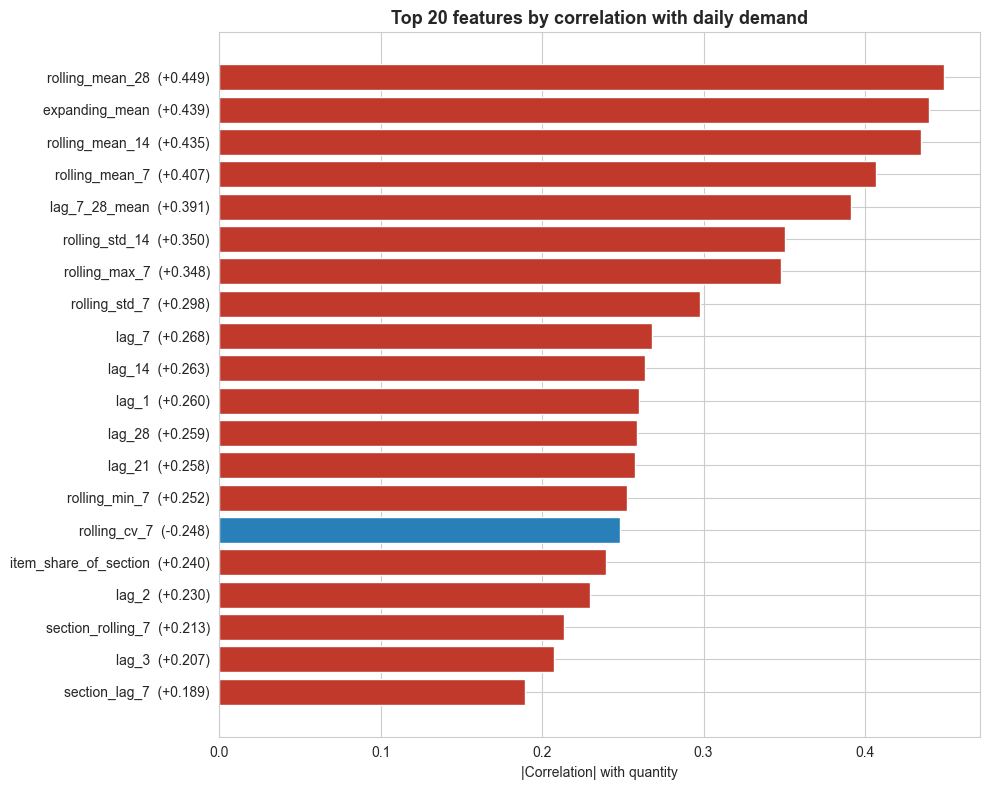


Top 10:
  +0.4489  rolling_mean_28
  +0.4395  expanding_mean
  +0.4350  rolling_mean_14
  +0.4067  rolling_mean_7
  +0.3912  lag_7_28_mean
  +0.3503  rolling_std_14
  +0.3479  rolling_max_7
  +0.2980  rolling_std_7
  +0.2679  lag_7
  +0.2635  lag_14


In [16]:
correlations = df_feat[feature_cols + ['quantity']].corr()['quantity'].drop('quantity')
top_corr = correlations.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#c0392b' if correlations[f] > 0 else '#2980b9' for f in top_corr.index]
bars = ax.barh(range(len(top_corr)), top_corr.values, color=colors)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels([f"{f}  ({correlations[f]:+.3f})" for f in top_corr.index], fontsize=10)
ax.set_xlabel('|Correlation| with quantity')
ax.set_title('Top 20 features by correlation with daily demand')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10:")
for f in top_corr.head(10).index:
    print(f"  {correlations[f]:+.4f}  {f}")

## 14. Save the feature matrix

Three files saved:
1. **`forecasting_features.csv`** — the full feature matrix (used by all modeling notebooks)
2. **`encoding_maps.json`** — label encoding dictionaries (needed at inference time)
3. **`feature_lists.json`** — column lists split by model type (tree vs DL features differ)

In [17]:
# ── Save feature matrix ──
output_path = os.path.join(DATASETS_DIR, 'forecasting_features.csv')
df_feat.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"  Shape: {df_feat.shape}")
print(f"  Train: {(df_feat['split']=='train').sum():,} rows")
print(f"  Val:   {(df_feat['split']=='val').sum():,} rows")
print(f"  Test:  {(df_feat['split']=='test').sum():,} rows")

# ── Save encoding maps ──
encoding_maps = {
    'section_map': section_map,
    'category_map': category_map,
    'item_map': item_map,
    'holiday_type_map': holiday_type_map,
}
maps_path = os.path.join(FE_DIR, 'encoding_maps.json')
with open(maps_path, 'w') as f:
    json.dump(encoding_maps, f, indent=2)
print(f"Saved: {maps_path}")

# ── Save feature column lists ──
# Tree models (XGBoost/LightGBM): use one-hot day_of_week, skip sin/cos
# DL models (LSTM/TFT): use sin/cos cyclical, skip one-hot
tree_features = [c for c in feature_cols if c not in
                 ['dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'woy_sin', 'woy_cos']
                 and 'month_sin_x_' not in c and 'month_cos_x_' not in c]
dl_features = [c for c in feature_cols if c not in
               ['dow_mon', 'dow_tue', 'dow_wed', 'dow_thu', 'dow_fri', 'dow_sat', 'dow_sun']]

feature_list = {
    'all_features': feature_cols,
    'tree_features': tree_features,
    'dl_features': dl_features,
    'target': 'quantity',
    'meta_cols': meta_cols,
}
lists_path = os.path.join(FE_DIR, 'feature_lists.json')
with open(lists_path, 'w') as f:
    json.dump(feature_list, f, indent=2)
print(f"Saved: {lists_path}")

Saved: ../../datasets\forecasting_features.csv
  Shape: (63318, 100)
  Train: 48,434 rows
  Val:   7,442 rows
  Test:  7,442 rows
Saved: ../Feature_engineering\encoding_maps.json
Saved: ../Feature_engineering\feature_lists.json


## 15. Final verification

In [18]:
print("=" * 60)
print("FINAL VERIFICATION")
print("=" * 60)

# Check 1: No NaN
nan_check = df_feat[feature_cols].isna().sum()
nan_features = nan_check[nan_check > 0]
if len(nan_features) == 0:
    print("✓ No NaN in any feature column")
else:
    print(f"✗ NaN found in: {dict(nan_features)}")

# Check 2: No data leakage
print("✓ All lag features use shift() — no future data leakage")
print("✓ All rolling features use shift(1) — no current-day leakage")

# Check 3: Split boundaries
print(f"\nSplit boundaries:")
for s in ['train', 'val', 'test']:
    sub = df_feat[df_feat['split'] == s]
    print(f"  {s:5s}: {sub['order_date'].min().date()} → {sub['order_date'].max().date()}  ({len(sub):,} rows, {sub['order_date'].nunique()} days)")

# Check 4: Feature count
print(f"\n✓ Total features: {len(feature_cols)}")
print(f"  Tree model features: {len(tree_features)}")
print(f"  DL model features:   {len(dl_features)}")
print(f"✓ Total rows: {len(df_feat):,}")

print(f"\n{'=' * 60}")
print("NOTEBOOK 03 COMPLETE")
print(f"{'=' * 60}")
print(f"\nNext: 04a_prophet.ipynb — Prophet baseline on all 122 items")

FINAL VERIFICATION
✓ No NaN in any feature column
✓ All lag features use shift() — no future data leakage
✓ All rolling features use shift(1) — no current-day leakage

Split boundaries:
  train: 2023-01-29 → 2024-02-29  (48,434 rows, 397 days)
  val  : 2024-03-01 → 2024-04-30  (7,442 rows, 61 days)
  test : 2024-05-01 → 2024-06-30  (7,442 rows, 61 days)

✓ Total features: 92
  Tree model features: 72
  DL model features:   85
✓ Total rows: 63,318

NOTEBOOK 03 COMPLETE

Next: 04a_prophet.ipynb — Prophet baseline on all 122 items
